# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras  # Lo importamos directamente
from keras.applications import VGG16 # Lo traemos directo desde keras


## Definiciones de modelos

In [6]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
from keras.datasets import cifar10
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Cargar el dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2. Normalizar los píxeles (de 0-255 a 0-1) para que la red aprenda más rápido
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Convertir las etiquetas a One-Hot Encoding (10 clases en CIFAR-10)
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 4. Configurar el Data Augmentation
# Esto rotará y moverá ligeramente las imágenes de entrenamiento 
# para que la red no se memorice las fotos y generalice mejor.
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train)

print(f"Forma de x_train: {x_train.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step


c:\Users\Guych\Documents\hybridge\Aprendizaje de Máquina\procesamiento_de_datos\.venv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Forma de x_train: (50000, 32, 32, 3)


In [8]:
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from keras.applications import VGG16

# --- MODELO 1: CNN Sencilla ---
modelo_simple = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
], name="CNN_Sencilla")

# --- MODELO 2: CNN Profunda con Regularización ---
modelo_profundo = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
], name="CNN_Profunda_Reg")

# --- MODELO 3: Transfer Learning (VGG16) ---
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

for layer in base_vgg.layers:
    layer.trainable = False

x = Flatten()(base_vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
salida_vgg = Dense(10, activation='softmax')(x)

modelo_transfer = Model(inputs=base_vgg.input, outputs=salida_vgg, name="Transfer_VGG16")

print("Modelos generados exitosamente.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Modelos generados exitosamente.


## Entrenamiento de modelos.

In [9]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
# Guardaremos el historial de cada modelo para compararlos después
historiales = {}
modelos = [modelo_simple, modelo_profundo, modelo_transfer]

epochs = 10 # 10 épocas para no saturar tu computadora
batch_size = 64

for modelo in modelos:
    print(f"\n{'='*40}")
    print(f"Iniciando entrenamiento de: {modelo.name}")
    print(f"{'='*40}")
    
    # Compilación
    modelo.compile(
        optimizer='adam', 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    # Entrenamiento con Data Augmentation
    historia = modelo.fit(
        datagen.flow(x_train, y_train_cat, batch_size=batch_size),
        epochs=epochs,
        validation_data=(x_test, y_test_cat),
        verbose=1
    )
    
    historiales[modelo.name] = historia


Iniciando entrenamiento de: CNN_Sencilla


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 42ms/step - accuracy: 0.3958 - loss: 1.6893 - val_accuracy: 0.4700 - val_loss: 1.4815
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.4987 - loss: 1.4132 - val_accuracy: 0.5121 - val_loss: 1.3940
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.5194 - loss: 1.3509 - val_accuracy: 0.5561 - val_loss: 1.2495
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - accuracy: 0.5373 - loss: 1.3059 - val_accuracy: 0.5591 - val_loss: 1.2687
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 53ms/step - accuracy: 0.5503 - loss: 1.2642 - val_accuracy: 0.5964 - val_loss: 1.1401
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.5619 - loss: 1.2397 - val_accuracy: 0.6055 - val_loss: 1.1217
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.5717 - loss: 1.2174 - val_accuracy: 0.5577 - val_loss: 1.2707
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.5776 - loss: 1.1927 - 

## Estadística y gráficos

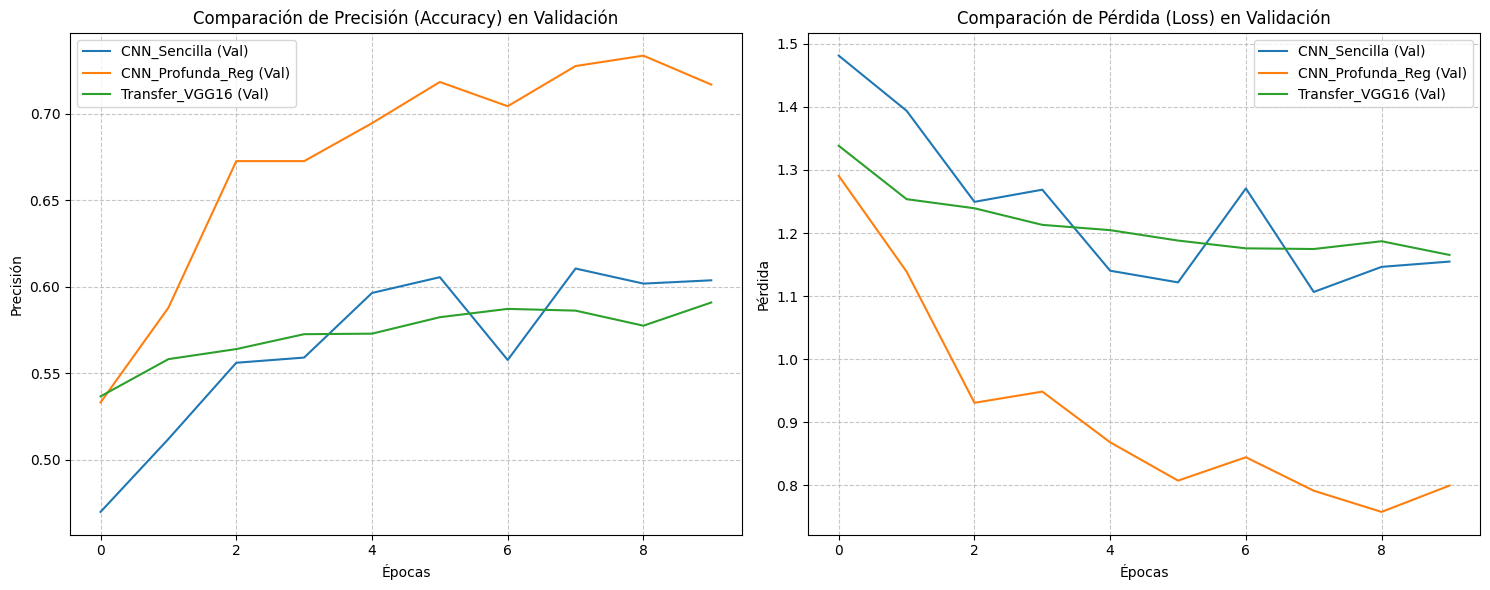

In [10]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
# Crear la figura para las dos gráficas
plt.figure(figsize=(15, 6))

# Gráfica 1: Precisión (Validation Accuracy)
plt.subplot(1, 2, 1)
for nombre, historia in historiales.items():
    plt.plot(historia.history['val_accuracy'], label=f'{nombre} (Val)')
plt.title('Comparación de Precisión (Accuracy) en Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfica 2: Pérdida (Validation Loss)
plt.subplot(1, 2, 2)
for nombre, historia in historiales.items():
    plt.plot(historia.history['val_loss'], label=f'{nombre} (Val)')
plt.title('Comparación de Pérdida (Loss) en Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

¿Cuál fue el mejor?
El mejor modelo de esta prueba fue la CNN Profunda con Regularización (línea naranja).

¿Por qué?
Alcanzó la mayor precisión en validación (~72%) y la menor pérdida. Al tener múltiples bloques convolucionales, la red tuvo la capacidad suficiente para extraer características complejas de las imágenes. Además, el uso estratégico de capas Dropout fue clave: evitó el sobreajuste (overfitting), permitiendo que el modelo generalizara mucho mejor que la CNN sencilla.

Por otro lado, el modelo de Transfer Learning (VGG16) tuvo un bajo rendimiento. Esto ocurre porque VGG16 está diseñada para imágenes grandes (224x224). Al introducirle las imágenes diminutas de CIFAR-10 (32x32), los múltiples Max Pooling de VGG16 reducen la imagen a prácticamente nada (1x1) antes de llegar a la capa densa, dejando a la red sin información útil para clasificar.

¿Cómo lo mejoraría?

Fine-Tuning para VGG16: En lugar de congelar toda la base (trainable = False), descongelaría los últimos dos bloques convolucionales de VGG16 para que sus pesos se adapten específicamente a las texturas de CIFAR-10. Además, usaría una capa UpSampling2D al inicio para agrandar las imágenes de 32x32 a al menos 64x64 antes de pasarlas por la VGG16.

Early Stopping y Callbacks: Implementaría la función EarlyStopping de Keras para entrenar por 30-50 épocas, permitiendo que la red se detenga automáticamente cuando detecte que la pérdida de validación ya no mejora, ahorrando tiempo y evitando el sobreajuste al final del entrenamiento.